<a href="https://colab.research.google.com/github/brenoSilva292/proUni_2020_DataScience/blob/main/Prouni_2020.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prouni - 2020
O Programa Universidade para Todos - Prouni tem como finalidade a concessão de bolsas de estudo integrais e parciais em cursos de graduação e sequenciais de formação específica, em instituições de ensino superior privadas que oferece, em contrapartida, isenção de tributos àquelas instituições que aderem ao Programa.Dirigido aos estudantes egressos do ensino médio da rede pública ou da rede particular na condição de bolsistas integrais, com renda familiar per capita máxima de três salários mínimos, o Prouni conta com um sistema de seleção informatizado e impessoal, que confere transparência e segurança ao processo. Os candidatos são selecionados pelas notas obtidas no **Exame Nacional do Ensino Médio - Enem** conjugando-se, desse modo, inclusão à qualidade e mérito dos estudantes com melhores desempenhos acadêmicos.

In [ ]:
# importar os pacote necessários
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Diz:mostre os gráficos diretamente dentro da célula
%matplotlib inline

In [ ]:
# importar o arquivo para um DataFrame
df = pd.read_csv("/content/sample_data/ProuniRelatorioDadosAbertos2020.csv",
                 encoding='latin1',
                 sep=';')


Conjunto de dados: Bolsas concedidas e perfil dos beneficiários do Prouni

# Dicionário das variáveis

- `ANO_CONCESSAO_BOLSA` - Ano da concessão da bolsa.
- `CODIGO_EMEC_IES_BOLSA` - Código do e-MEC da IES que concedeu a bolsa.
- `NOME_IES_BOLSA` - Nome/Razão Social da Instituição de Ensino Superior que concedeu a bolsa ProUni.
- `TIPO_BOLSA` - Descrição do tipo da bolsa concedida ao beneficiário do ProUni (integral – 100% ou parcial – 50%).
- `MODALIDADE_ENSINO_BOLSA` - Modalidade de ensino (presencial ou ensino à distância – EAD).
- `NOME_CURSO_BOLSA` - Nome do curso.
- `NOME_TURNO_CURSO_BOLSA` - Turno do curso.
- `CPF_BENEFICIARIO_BOLSA` - CPF do beneficiário.

## Detalhamento do perfil dos beneficiários do Prouni por:

- `SEXO_BENEFICIARIO_BOLSA` - Sexo do beneficiário.
- `RACA_BENEFICIARIO_BOLSA` - Raça/cor.
- `DT_NASCIMENTO_BENEFICIARIO` - Data de nascimento do beneficiário.
- `BENEFICIARIO_DEFICICIENTE_FISICO` - Indicação se o beneficiário é portador de deficiência.
- `REGIAO_BENEFICIARIO_BOLSA` - Região.
- `SIGLA_UF_BENEFICIARIO_BOLSA`- UF.
- `MUNICIPIO_BENEFICIARIO_BOLSA` - Município.

In [ ]:
# Mostrar as 5 primeiras entradas
df.head()

,ANO_CONCESSAO_BOLSA,CODIGO_EMEC_IES_BOLSA,NOME_IES_BOLSA,MUNICIPIO,CAMPUS,TIPO_BOLSA,MODALIDADE_ENSINO_BOLSA,NOME_CURSO_BOLSA,NOME_TURNO_CURSO_BOLSA,CPF_BENEFICIARIO,SEXO_BENEFICIARIO,RACA_BENEFICIARIO,DATA_NASCIMENTO,BENEFICIARIO_DEFICIENTE_FISICO,REGIAO_BENEFICIARIO,UF_BENEFICIARIO,MUNICIPIO_BENEFICIARIO
0,2020,322,UNIVERSIDADE PAULISTA,IPATINGA,IPATINGA,INTEGRAL,EAD,PEDAGOGIA,CURSO A DISTÂNCIA,991.XXX.XXX-91,F,Parda,11/08/1973,N,SUDESTE,MG,GOVERNADOR VALADARES
1,2020,163,UNIVERSIDADE ESTÁCIO DE SÁ,FORTALEZA,EAD VIA CORPVS - CE,INTEGRAL,EAD,MARKETING,CURSO A DISTÂNCIA,067.XXX.XXX-01,M,Parda,13/05/1987,N,NORDESTE,CE,FORTALEZA
2,2020,17670,FACULDADE DE QUIXERAMOBIM,QUIXERAMOBIM,FACULDADE DE QUIXERAMOBIM - UNIQ,INTEGRAL,PRESENCIAL,FARMÁCIA,NOTURNO,623.XXX.XXX-27,M,Parda,23/07/2001,N,NORDESTE,CE,MOMBACA
3,2020,203,UNIVERSIDADE SÃO JUDAS TADEU,SAO PAULO,PAULISTA,PARCIAL,PRESENCIAL,DIREITO,MATUTINO,089.XXX.XXX-40,F,Branca,04/04/2003,N,NORDESTE,BA,IBITITA
4,2020,203,UNIVERSIDADE SÃO JUDAS TADEU,SAO PAULO,PAULISTA,INTEGRAL,PRESENCIAL,DIREITO,MATUTINO,173.XXX.XXX-09,F,Branca,07/12/1977,N,SUDESTE,SP,SAO PAULO


In [ ]:
# Identificar o volume de dados do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166830 entries, 0 to 166829
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   ANO_CONCESSAO_BOLSA             166830 non-null  int64 
 1   CODIGO_EMEC_IES_BOLSA           166830 non-null  int64 
 2   NOME_IES_BOLSA                  166830 non-null  object
 3   MUNICIPIO                       166830 non-null  object
 4   CAMPUS                          166830 non-null  object
 5   TIPO_BOLSA                      166830 non-null  object
 6   MODALIDADE_ENSINO_BOLSA         166830 non-null  object
 7   NOME_CURSO_BOLSA                166792 non-null  object
 8   NOME_TURNO_CURSO_BOLSA          166830 non-null  object
 9   CPF_BENEFICIARIO                166830 non-null  object
 10  SEXO_BENEFICIARIO               166830 non-null  object
 11  RACA_BENEFICIARIO               166830 non-null  object
 12  DATA_NASCIMENTO               

In [ ]:
# Ver a quantidade de valores ausentes
df.isnull().sum()

,0
ANO_CONCESSAO_BOLSA,0
CODIGO_EMEC_IES_BOLSA,0
NOME_IES_BOLSA,0
MUNICIPIO,0
CAMPUS,0
TIPO_BOLSA,0
MODALIDADE_ENSINO_BOLSA,0
NOME_CURSO_BOLSA,38
NOME_TURNO_CURSO_BOLSA,0
CPF_BENEFICIARIO,0


In [ ]:
# Eliminando todas as entradas onde existam valores ausentes em "NOME_CURSO_BOLSA"
df_clean = df.dropna(subset=['NOME_CURSO_BOLSA'], axis=0)

# comparar o antes e o depois
print("Antes:\t{}".format(df.shape))
print("Depois:\t{}".format(df_clean.shape))

Antes:	(166830, 17)
Depois:	(166792, 17)


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 166792 entries, 0 to 166829
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   ANO_CONCESSAO_BOLSA             166792 non-null  int64 
 1   CODIGO_EMEC_IES_BOLSA           166792 non-null  int64 
 2   NOME_IES_BOLSA                  166792 non-null  object
 3   MUNICIPIO                       166792 non-null  object
 4   CAMPUS                          166792 non-null  object
 5   TIPO_BOLSA                      166792 non-null  object
 6   MODALIDADE_ENSINO_BOLSA         166792 non-null  object
 7   NOME_CURSO_BOLSA                166792 non-null  object
 8   NOME_TURNO_CURSO_BOLSA          166792 non-null  object
 9   CPF_BENEFICIARIO                166792 non-null  object
 10  SEXO_BENEFICIARIO               166792 non-null  object
 11  RACA_BENEFICIARIO               166792 non-null  object
 12  DATA_NASCIMENTO                 166

In [ ]:
# De object para datetime
df_clean['DATA_NASCIMENTO'] = pd.to_datetime(
    df_clean['DATA_NASCIMENTO'],
    dayfirst=True,
    errors='coerce'
)

# Formatação brasileira
df_clean['DATA_NASCIMENTO'] = df_clean['DATA_NASCIMENTO'].dt.strftime('%d/%m/%Y')

/tmp/ipykernel_25142/3176713182.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['DATA_NASCIMENTO'] = pd.to_datetime(
/tmp/ipykernel_25142/3176713182.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['DATA_NASCIMENTO'] = df_clean['DATA_NASCIMENTO'].dt.strftime('%d/%m/%Y')


# 1 - Desigualdade de Acesso

In [ ]:
df_clean.groupby(['RACA_BENEFICIARIO', 'TIPO_BOLSA']).size().unstack()

TIPO_BOLSA,INTEGRAL,PARCIAL
RACA_BENEFICIARIO,,
Amarela,2082,818
Branca,49552,14911
Ind¡gena,136,17
Não Informada,64,4
Parda,61621,16436
Preta,17256,3895


Os dados evidenciam que o acesso às bolsas não é equilibrado entre os grupos raciais. Enquanto pessoas pardas e brancas concentram a maior parte dos benefícios, grupos como indígenas e não informados aparecem com participação mínima, indicando possíveis barreiras de acesso.

Isso sugere que, embora exista inclusão, ela ainda não é suficiente para reduzir desigualdades históricas. O desafio não é apenas ampliar o número de bolsas, mas garantir uma distribuição mais justa e acessível a todos.

---

# 2 - EAD está sendo mais usado por quem recebe bolsa parcial?

A função `pd.crosstab` do Pandas serve para calcular tabelas de contingência (ou tabelas cruzadas) de duas ou mais colunas categóricas

MODALIDADE_ENSINO_BOLSA       EAD  PRESENCIAL
TIPO_BOLSA                                   
INTEGRAL                 0.386104    0.613896
PARCIAL                  0.092874    0.907126


<Axes: xlabel='TIPO_BOLSA'>

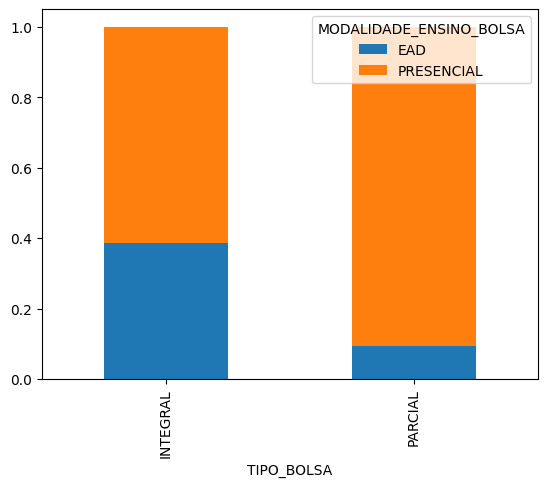

In [ ]:
tabela = pd.crosstab(
    df_clean['TIPO_BOLSA'],
    df_clean['MODALIDADE_ENSINO_BOLSA'],
    normalize='index'
)

print(tabela)

tabela.plot(kind='bar', stacked=True)

a modalidade presencial domina amplamente a concessão de bolsas, especialmente nas parciais.

- Enquanto as bolsas integrais ainda têm uma participação relevante no EAD (38%), nas bolsas parciais o EAD praticamente desaparece (9%). Isso indica que:

- O ensino presencial é o principal canal de distribuição de bolsas, sobretudo as parciais.
O EAD está subaproveitado como ferramenta de inclusão, mesmo tendo potencial de escala e menor custo.

Em termos estratégicos, isso revela uma oportunidade clara: expandir bolsas (principalmente parciais) no EAD pode aumentar o acesso de forma mais eficiente e abrangente.

---